In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, CairoMakie, FHist
using Distributions, Statistics, SpecialFunctions
using JLD2, CSV, LaTeXStrings

In [3]:
include("./utils.jl")
using .Utils

In [4]:
@load "./Data/processed/microbiome.jld2" MICROBIOME;
# @load "./Data/processed/genetic.jld2" GENETIC;
# @load "./Data/processed/books.jld2" BOOKS;
# @load "./Data/processed/mobility.jld2" MOBILITY;
# @load "./Data/processed/null_model.jld2" NULL_MODEL;
# @load "./Data/processed/null_model2.jld2" NULL_MODEL2;

DF = deepcopy(MICROBIOME);

In [5]:
Utils.df_filter!(DF; min_samples=5e1, min_nreads=1e4);

In [8]:
fig = Figure(size = (1000, 500))
ax = Axis(fig[1, 1]; yscale=log10, limits=((-4.5,4),(1e-10,5e0)),
            xlabel=L"\text{z}", ylabel=L"\text{pdf}", title=L"\text{distribution}",
            xlabelsize=18, ylabelsize=18, titlesize=18)

envs = unique(DF.env)
for e in envs
    println(e)
    df = DF[DF.env .== e, :]
    counts, nreads = Utils.get_counts(df, occ=1)
    freqs = counts ./ nreads
    
    X = log.(nreads .* abs.(log.((1 .- freqs) ./ freqs)))    
    Z = (X .- mean(X, dims=2)) ./ std(X, dims=2)
    data = vcat(Z...)
    data = data[.!isnan.(data)]
    data = data[.!isinf.(data)]
    
    if length(data) < 2
        continue
    end

    bmin, bmax = round(minimum(data)), round(maximum(data))
    Δb = (bmax - bmin) / 30
    fh = FHist.Hist1D(data, binedges=bmin:Δb:bmax)
    ctrs = bincenters(fh)
    pdf  = bincounts(fh) ./ (integral(fh) * Δb)
    
    mask = pdf .> 0
    ctrs = ctrs[mask]
    pdf = pdf[mask]

    scatter!(ax, ctrs, 10 .^ log.(pdf);
         label=e,
         markersize=12, strokewidth=0.8, strokecolor=:black)
end

SEAWATER
RIVER
ORAL
ORALCAVITY
GUT
AQUA1
SLUDGE
LAKE
SOIL


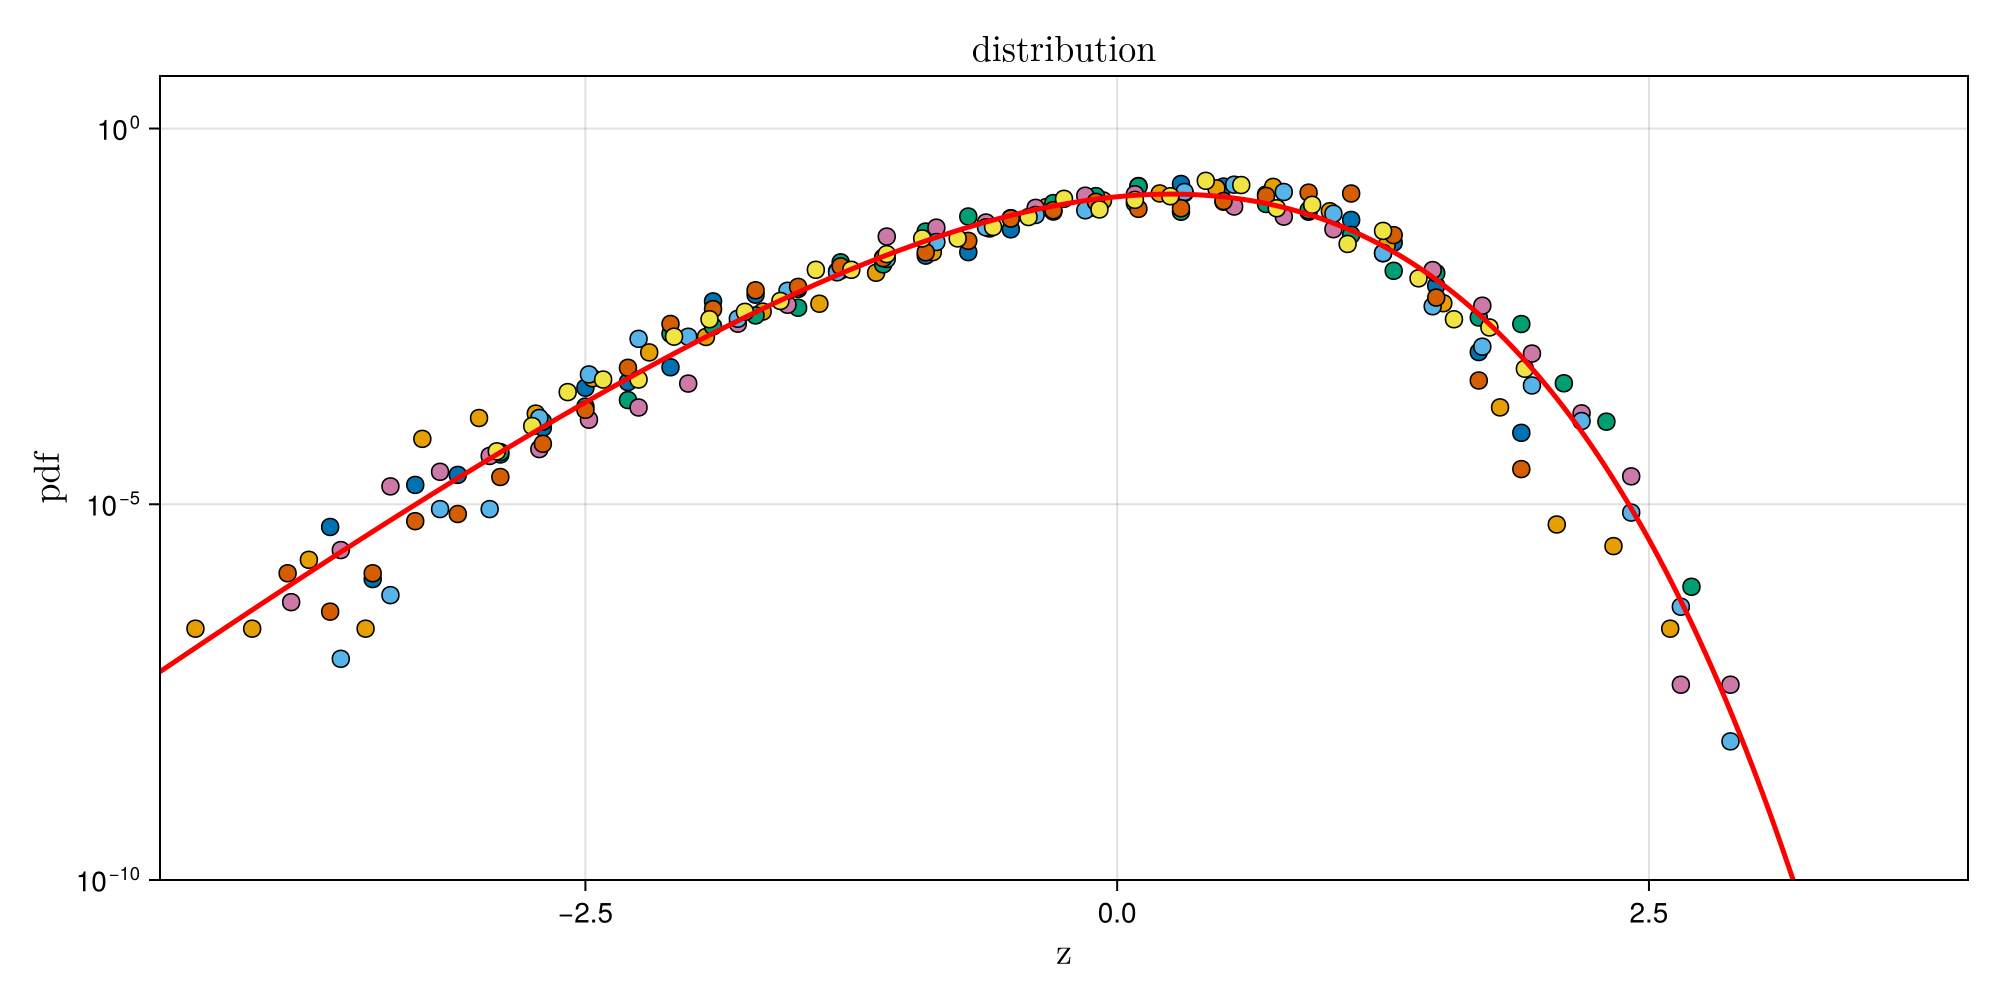

In [9]:
zrange = -10:0.01:10;
lines!(ax, zrange, 10 .^ Utils.lrg(zrange, 3.7); color=:red, linewidth=2.5, linestyle=:solid)
fig